***Fine Tuning***

In [1]:
import datetime

In [2]:
print(datetime.datetime.now())

2026-08-27 19:10:11.408373


In [3]:
import tensorflow as tf

In [4]:
import datetime
import tensorflow as tf


def create_tensorboard_callback(dir_name, experiment_name):
    log_dir = dir_name + "/" + experiment_name + "/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

    tensorboard_callback = tf.keras.callbacks.TensorBoard(
        log_dir=log_dir
    )

    print(f"Saving TensorBoard log files to: {log_dir}")

    return tensorboard_callback

In [5]:
import os 
for dirpath,dirnames,filenames in os.walk(r'D:\tensorflow\10_food_classes_10_percent'):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}")

There are 2 directories and 0 images in D:\tensorflow\10_food_classes_10_percent
There are 10 directories and 0 images in D:\tensorflow\10_food_classes_10_percent\test
There are 0 directories and 250 images in D:\tensorflow\10_food_classes_10_percent\test\chicken_curry
There are 0 directories and 250 images in D:\tensorflow\10_food_classes_10_percent\test\chicken_wings
There are 0 directories and 250 images in D:\tensorflow\10_food_classes_10_percent\test\fried_rice
There are 0 directories and 250 images in D:\tensorflow\10_food_classes_10_percent\test\grilled_salmon
There are 0 directories and 250 images in D:\tensorflow\10_food_classes_10_percent\test\hamburger
There are 0 directories and 250 images in D:\tensorflow\10_food_classes_10_percent\test\ice_cream
There are 0 directories and 250 images in D:\tensorflow\10_food_classes_10_percent\test\pizza
There are 0 directories and 250 images in D:\tensorflow\10_food_classes_10_percent\test\ramen
There are 0 directories and 250 images in 

In [6]:
train_dir = r"10_food_classes_10_percent/train/"
test_dir = "10_food_classes_10_percent/test/"

In [7]:
# Create data inputs
import tensorflow as tf
IMG_SIZE = (224, 224) # define image size
train_data_10_percent = tf.keras.preprocessing.image_dataset_from_directory(directory=train_dir,
                                                                            image_size=IMG_SIZE,
                                                                            label_mode="categorical", # what type are the labels?
                                                                            batch_size=32) # batch_size is 32 by default, this is generally a good number
test_data_10_percent = tf.keras.preprocessing.image_dataset_from_directory(directory=test_dir,
                                                                           image_size=IMG_SIZE,
                                                                           label_mode="categorical")

Found 750 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.


In [8]:
train_data_10_percent

<BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 10), dtype=tf.float32, name=None))>

In [9]:
train_data_10_percent.class_names

['chicken_curry',
 'chicken_wings',
 'fried_rice',
 'grilled_salmon',
 'hamburger',
 'ice_cream',
 'pizza',
 'ramen',
 'steak',
 'sushi']

In [10]:
for images, labels in train_data_10_percent.take(1):
    print(images,labels)

tf.Tensor(
[[[[ 69.57143     85.57143     85.57143   ]
   [ 66.95408     82.95408     82.95408   ]
   [ 66.78062     84.35204     84.35204   ]
   ...
   [ 43.653076    54.653076    58.224487  ]
   [ 45.663277    56.663277    58.663277  ]
   [ 45.37245     55.37245     57.37245   ]]

  [[ 69.42857     85.42857     85.42857   ]
   [ 67.07143     83.07143     83.07143   ]
   [ 66.341835    83.91326     83.91326   ]
   ...
   [ 43.12755     54.12755     57.69896   ]
   [ 43.0051      54.0051      56.0051    ]
   [ 43.168373    53.168373    55.168373  ]]

  [[ 67.14796     83.14796     83.14796   ]
   [ 66.015305    82.015305    82.015305  ]
   [ 66.04592     83.61735     83.61735   ]
   ...
   [ 42.239803    53.239803    56.811214  ]
   [ 44.316353    55.316353    57.316353  ]
   [ 47.367344    57.367344    59.367344  ]]

  ...

  [[ 83.63249     93.63249     85.63249   ]
   [ 88.98461     98.98461     90.98461   ]
   [ 90.19378    100.19378     92.19378   ]
   ...
   [ 98.33673    107.954

In [11]:
#1.Crete a Base model 
base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(include_top=False)

#2. Freeze base model
base_model.trainable = False

#3. create a inputs into base model
inputs = tf.keras.layers.Input(shape=(224,224,3),name="input_layer")

#4.pass the input in to base model
x= base_model(inputs)

print(f"shape after base model:{x.shape}")

#5. Average pool the outputs of the base model

x = tf.keras.layers.GlobalAveragePooling2D(name='global_average_pooling_layer')(x)
print(f"After GlobleAvaragePooling2D(): {x.shape}")

#6. Create out activation layer 

outputs = tf.keras.layers.Dense(10, activation="softmax", name="output_layer")(x)

#7. combine the in put and outputs

model_0 = tf.keras.Model(inputs,outputs)

#8.comile
model_0.compile(loss='categorical_crossentropy',
               optimizer = tf.keras.optimizers.Adam(),
               metrics='accuracy')

#fit
histroy_10_percent=model_0.fit(train_data_10_percent,
                               epochs=5,
                               steps_per_epoch=len(train_data_10_percent),
                               validation_data=test_data_10_percent,
                               validation_steps=int(0.25 * len(test_data_10_percent)),
                               callbacks=[create_tensorboard_callback('5.transefer_learning','10_food_classes_10_percent')])





shape after base model:(None, 7, 7, 1280)
After GlobleAvaragePooling2D(): (None, 1280)
Saving TensorBoard log files to: 5.transefer_learning/10_food_classes_10_percent/20260827-191020
Epoch 1/5
24/24 [==============================] - 16s 240ms/step - loss: 1.9572 - accuracy: 0.3667 - val_loss: 1.3808 - val_accuracy: 0.7072
Epoch 2/5
24/24 [==============================] - 4s 162ms/step - loss: 1.1761 - accuracy: 0.7400 - val_loss: 0.9015 - val_accuracy: 0.7993
Epoch 3/5
24/24 [==============================] - 4s 159ms/step - loss: 0.8618 - accuracy: 0.8093 - val_loss: 0.7192 - val_accuracy: 0.8520
Epoch 4/5
24/24 [==============================] - 4s 157ms/step - loss: 0.6971 - accuracy: 0.8533 - val_loss: 0.6482 - val_accuracy: 0.8487
Epoch 5/5
24/24 [==============================] - 4s 162ms/step - loss: 0.5935 - accuracy: 0.8613 - val_loss: 0.5605 - val_accuracy: 0.8586


In [12]:
for layer_number, layer in enumerate(base_model.layers):
    print(layer_number,layer)

0 <keras.engine.input_layer.InputLayer object at 0x00000212C9AD7A90>
1 <keras.layers.preprocessing.image_preprocessing.Rescaling object at 0x00000212C9ACB130>
2 <keras.layers.preprocessing.normalization.Normalization object at 0x00000212C9AF8D90>
3 <keras.layers.convolutional.conv2d.Conv2D object at 0x00000212C9AF8DF0>
4 <keras.layers.normalization.batch_normalization.BatchNormalization object at 0x00000212C9BC2430>
5 <keras.layers.core.activation.Activation object at 0x00000212FCDFFF40>
6 <keras.layers.convolutional.conv2d.Conv2D object at 0x00000212C9C1FCD0>
7 <keras.layers.normalization.batch_normalization.BatchNormalization object at 0x00000212C9C1FD30>
8 <keras.layers.core.activation.Activation object at 0x00000212C9C1FDC0>
9 <keras.layers.convolutional.conv2d.Conv2D object at 0x00000212C9C2AD60>
10 <keras.layers.normalization.batch_normalization.BatchNormalization object at 0x00000212C9C46B50>
11 <keras.layers.core.activation.Activation object at 0x00000212C9C46340>
12 <keras.lay

In [13]:
base_model.summary()

Model: "efficientnetv2-b0"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, None, None,  0           []                               
                                 3)]                                                              
                                                                                                  
 rescaling (Rescaling)          (None, None, None,   0           ['input_1[0][0]']                
                                3)                                                                
                                                                                                  
 normalization (Normalization)  (None, None, None,   0           ['rescaling[0][0]']              
                                3)                                                

In [14]:
model_0.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 efficientnetv2-b0 (Function  (None, None, None, 1280)  5919312  
 al)                                                             
                                                                 
 global_average_pooling_laye  (None, 1280)             0         
 r (GlobalAveragePooling2D)                                      
                                                                 
 output_layer (Dense)        (None, 10)                12810     
                                                                 
Total params: 5,932,122
Trainable params: 12,810
Non-trainable params: 5,919,312
_________________________________________________________________


In [15]:
# If you wanted to, you could really turn this into a helper function to load in with a helper.py script...
import matplotlib.pyplot as plt

# Plot the validation and training data separately
def plot_loss_curves(history):
  """
  Returns separate loss curves for training and validation metrics.
  """ 
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']

  epochs = range(len(history.history['loss']))

  # Plot loss
  plt.plot(epochs, loss, label='training_loss')
  plt.plot(epochs, val_loss, label='val_loss')
  plt.title('Loss')
  plt.xlabel('Epochs')
  plt.legend()

  # Plot accuracy
  plt.figure()
  plt.plot(epochs, accuracy, label='training_accuracy')
  plt.plot(epochs, val_accuracy, label='val_accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.legend();

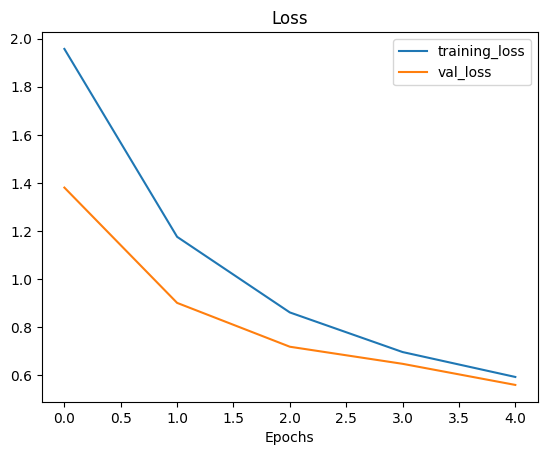

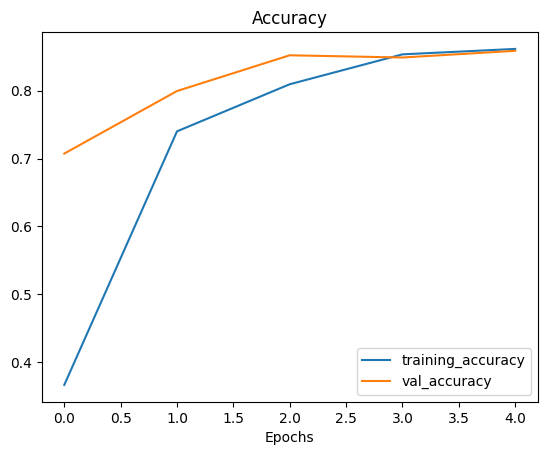

In [16]:
plot_loss_curves(histroy_10_percent)

In [17]:
#Define inputs tenson shape 
input_shape = (1,4,4,3)

#Create a Random Tensor
tf.random.set_seed(42)

input_tensor = tf.random.normal(input_shape)
print(f"Random input tensor:\n {input_tensor}\n")

#pass the random tensor through a global average pooling 2D layer
global_average_pooled_tensor = tf.keras.layers.GlobalAveragePooling2D()(input_tensor)
print(f"2D global average pooled random tensor: \n {global_average_pooled_tensor}\n")

#Check the shapes of the different tensors
print(input_tensor.shape)
print(global_average_pooled_tensor.shape)

Random input tensor:
 [[[[ 0.3274685  -0.8426258   0.3194337 ]
   [-1.4075519  -2.3880599  -1.0392479 ]
   [-0.5573232   0.539707    1.6994323 ]
   [ 0.28893656 -1.5066116  -0.2645474 ]]

  [[-0.59722406 -1.9171132  -0.62044144]
   [ 0.8504023  -0.40604794 -3.0258412 ]
   [ 0.9058464   0.29855987 -0.22561555]
   [-0.7616443  -1.8917141  -0.93847126]]

  [[ 0.77852213 -0.47338897  0.97772694]
   [ 0.24694404  0.20573747 -0.5256233 ]
   [ 0.32410017  0.02545409 -0.10638497]
   [-0.6369475   1.1603122   0.2507359 ]]

  [[-0.41728503  0.4012578  -1.4145443 ]
   [-0.5931857  -1.6617213   0.33567193]
   [ 0.10815629  0.23479682 -0.56668764]
   [-0.35819843  0.88698614  0.52744764]]]]

2D global average pooled random tensor: 
 [[-0.09368646 -0.45840448 -0.2885598 ]]

(1, 4, 4, 3)
(1, 3)


In [18]:
tf.reduce_mean(input_tensor, axis=[1,2])

<tf.Tensor: shape=(1, 3), dtype=float32, numpy=array([[-0.09368646, -0.45840448, -0.2885598 ]], dtype=float32)>

In [19]:
for dirpath,dirnames,filenames in os.walk(r'D:\tensorflow\10_food_classes_1_percent'):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}")

There are 2 directories and 0 images in D:\tensorflow\10_food_classes_1_percent
There are 10 directories and 0 images in D:\tensorflow\10_food_classes_1_percent\test
There are 0 directories and 250 images in D:\tensorflow\10_food_classes_1_percent\test\chicken_curry
There are 0 directories and 250 images in D:\tensorflow\10_food_classes_1_percent\test\chicken_wings
There are 0 directories and 250 images in D:\tensorflow\10_food_classes_1_percent\test\fried_rice
There are 0 directories and 250 images in D:\tensorflow\10_food_classes_1_percent\test\grilled_salmon
There are 0 directories and 250 images in D:\tensorflow\10_food_classes_1_percent\test\hamburger
There are 0 directories and 250 images in D:\tensorflow\10_food_classes_1_percent\test\ice_cream
There are 0 directories and 250 images in D:\tensorflow\10_food_classes_1_percent\test\pizza
There are 0 directories and 250 images in D:\tensorflow\10_food_classes_1_percent\test\ramen
There are 0 directories and 250 images in D:\tensorf

In [20]:
train_dir_1_percent = r'D:\tensorflow\10_food_classes_1_percent\train'
test_dir = r'D:\tensorflow\10_food_classes_1_percent\test'

In [21]:
import tensorflow as tf
IMG_SIZE = (224, 224)
train_data_1_percent = tf.keras.preprocessing.image_dataset_from_directory(train_dir_1_percent,
                                                                           label_mode="categorical",
                                                                           batch_size=32, # default
                                                                           image_size=IMG_SIZE)
test_data = tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                                label_mode="categorical",
                                                                image_size=IMG_SIZE)

Found 70 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.


In [22]:
import tensorflow as tf 
from tensorflow.keras import layers
from tensorflow import keras

In [23]:
data_augmentation = keras.Sequential([
  layers.RandomFlip("vertical"),
  layers.RandomRotation(0.3),
  layers.RandomZoom(0.3),
  layers.RandomHeight(0.3),
  layers.RandomWidth(0.3),
], name ="data_augmentation")


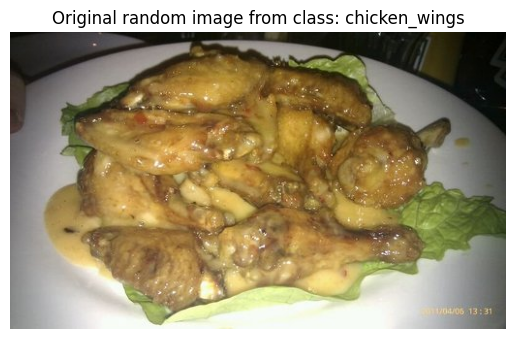

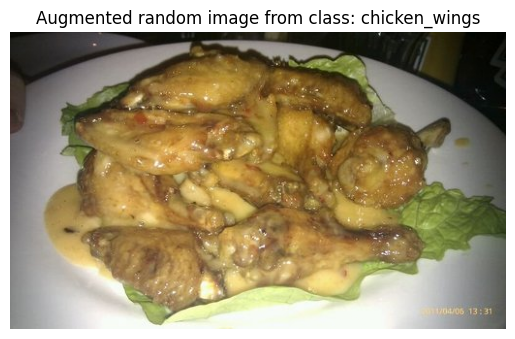

In [24]:
# View a random image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random
target_class = random.choice(train_data_1_percent.class_names) # choose a random class
target_dir = "10_food_classes_1_percent/train/" + target_class # create the target directory
random_image = random.choice(os.listdir(target_dir)) # choose a random image from target directory
random_image_path = target_dir + "/" + random_image # create the choosen random image path
img = mpimg.imread(random_image_path) # read in the chosen target image
plt.imshow(img) # plot the target image
plt.title(f"Original random image from class: {target_class}")
plt.axis(False); # turn off the axes

# Augment the image
augmented_img = data_augmentation(tf.expand_dims(img, axis=0)) # data augmentation model requires shape (None, height, width, 3)
plt.figure()
plt.imshow(tf.squeeze(augmented_img)/255.) # requires normalization after augmentation
plt.title(f"Augmented random image from class: {target_class}")
plt.axis(False);

In [29]:
input_shape=(224,224,3)
base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(include_top=False)
base_model.trainable=False

inputs = layers.Input(shape=input_shape,name='input_layer')

x = data_augmentation(inputs)

x = base_model(x, training=False)

x=layers.GlobalAveragePooling2D(name='glabel_average_pooling_layer')(x)

outputs = layers.Dense(10, activation='softmax', name= 'output_layer')(x)

model_1 = keras.Model(inputs,outputs)

# Compile the model
model_1.compile(loss="categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

# Fit the model
history_1_percent = model_1.fit(train_data_1_percent,
                    epochs=5,
                    steps_per_epoch=len(train_data_1_percent),
                    validation_data=test_data,
                    validation_steps=int(0.25* len(test_data)), # validate for less steps
                    # Track model training logs
                    callbacks=[create_tensorboard_callback("transfer_learning", "1_percent_data_aug")])

Saving TensorBoard log files to: transfer_learning/1_percent_data_aug/20260827-191833
Epoch 1/5
3/3 [==============================] - 12s 2s/step - loss: 2.4200 - accuracy: 0.0857 - val_loss: 2.2478 - val_accuracy: 0.1480
Epoch 2/5
3/3 [==============================] - 3s 1s/step - loss: 2.1316 - accuracy: 0.2571 - val_loss: 2.1435 - val_accuracy: 0.2023
Epoch 3/5
3/3 [==============================] - 3s 1s/step - loss: 1.9931 - accuracy: 0.3000 - val_loss: 2.0359 - val_accuracy: 0.2878
Epoch 4/5
3/3 [==============================] - 3s 1s/step - loss: 1.8218 - accuracy: 0.4429 - val_loss: 1.9468 - val_accuracy: 0.3569
Epoch 5/5
3/3 [==============================] - 3s 1s/step - loss: 1.7466 - accuracy: 0.5143 - val_loss: 1.8628 - val_accuracy: 0.4243


In [30]:
model_1.summary()

Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 data_augmentation (Sequenti  (None, None, None, 3)    0         
 al)                                                             
                                                                 
 efficientnetv2-b0 (Function  (None, None, None, 1280)  5919312  
 al)                                                             
                                                                 
 glabel_average_pooling_laye  (None, 1280)             0         
 r (GlobalAveragePooling2D)                                      
                                                                 
 output_layer (Dense)        (None, 10)                12810     
                                                           

In [31]:
# Evaluate on the test data
results_1_percent_data_aug = model_1.evaluate(test_data)
results_1_percent_data_aug

79/79 [==============================] - 8s 95ms/step - loss: 1.8696 - accuracy: 0.4192


[1.8695980310440063, 0.41920000314712524]

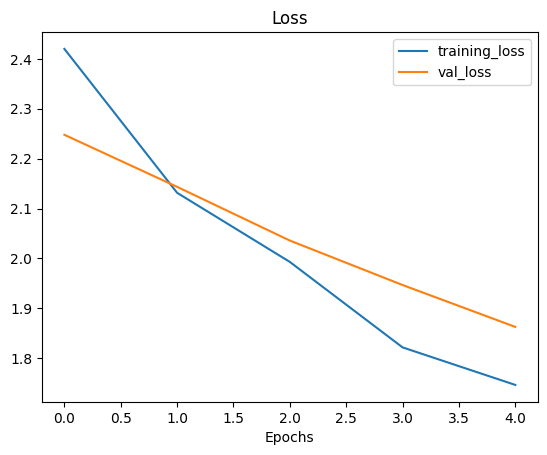

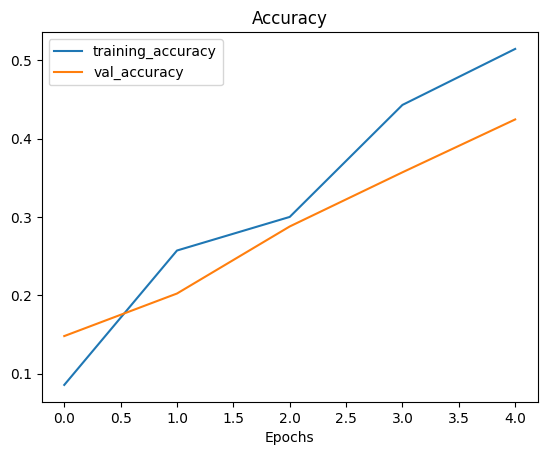

In [32]:
plot_loss_curves(history_1_percent)

In [33]:
train_dir_10_percent = "10_food_classes_10_percent/train/"
test_dir = "10_food_classes_10_percent/test/"

In [34]:
import tensorflow as tf
IMG_SIZE = (224, 224)
train_data_10_percent = tf.keras.preprocessing.image_dataset_from_directory(train_dir_10_percent,
                                                                            label_mode="categorical",
                                                                            image_size=IMG_SIZE)

test_data = tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                                label_mode="categorical",
                                                                image_size=IMG_SIZE)

Found 750 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.


In [35]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

data_augmentation = keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.2),
  layers.RandomHeight(0.2),
  layers.RandomWidth(0.2),
  
], name ="data_augmentation")

input_shape = (224, 224, 3)

base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(include_top=False)
base_model.trainable = False

inputs = layers.Input(shape=input_shape, name="input_layer") 
x = data_augmentation(inputs) 
x = base_model(x, training=False) 
x = layers.GlobalAveragePooling2D(name="global_average_pooling_layer")(x)
outputs = layers.Dense(10, activation="softmax", name="output_layer")(x)
model_2 = tf.keras.Model(inputs, outputs)

model_2.compile(loss="categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=["accuracy"])

In [36]:
def create_base_model(input_shape: tuple[int, int, int] = (224, 224, 3),
                      output_shape: int = 10,
                      learning_rate: float = 0.001,
                      training: bool = False) -> tf.keras.Model:


    base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(include_top=False)
    base_model.trainable = training


    inputs = layers.Input(shape=input_shape, name="input_layer")
    x = data_augmentation(inputs)
    x = base_model(x, training=False)  
    x = layers.GlobalAveragePooling2D(name="global_average_pooling_layer")(x)
    outputs = layers.Dense(units=output_shape, activation="softmax", name="output_layer")(x)
    model = tf.keras.Model(inputs, outputs)


    model.compile(loss="categorical_crossentropy",
                  optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  metrics=["accuracy"])

    return model
model_2 = create_base_model()

In [37]:
# Setup checkpoint path
checkpoint_path = "ten_percent_model_checkpoints_weights/checkpoint.ckpt" 
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                                         save_weights_only=True, 
                                                         save_best_only=True, 
                                                         save_freq="epoch",
                                                         verbose=1)

In [38]:
initial_epochs = 5
history_10_percent_data_aug = model_2.fit(train_data_10_percent,
                                          epochs=initial_epochs,
                                          validation_data=test_data,
                                          validation_steps=int(0.25 * len(test_data)),
                                          callbacks=[create_tensorboard_callback("transfer_learning", "10_percent_data_aug"),
                                                     checkpoint_callback])

Saving TensorBoard log files to: transfer_learning/10_percent_data_aug/20260827-192427
Epoch 1/5
24/24 [==============================] - ETA: 0s - loss: 2.0328 - accuracy: 0.2920
Epoch 1: val_loss improved from inf to 1.53630, saving model to ten_percent_model_checkpoints_weights\checkpoint.ckpt
24/24 [==============================] - 21s 578ms/step - loss: 2.0328 - accuracy: 0.2920 - val_loss: 1.5363 - val_accuracy: 0.6086
Epoch 2/5
24/24 [==============================] - ETA: 0s - loss: 1.4383 - accuracy: 0.6400
Epoch 2: val_loss improved from 1.53630 to 1.09112, saving model to ten_percent_model_checkpoints_weights\checkpoint.ckpt
24/24 [==============================] - 11s 439ms/step - loss: 1.4383 - accuracy: 0.6400 - val_loss: 1.0911 - val_accuracy: 0.7566
Epoch 3/5
24/24 [==============================] - ETA: 0s - loss: 1.1300 - accuracy: 0.7427
Epoch 3: val_loss improved from 1.09112 to 0.85266, saving model to ten_percent_model_checkpoints_weights\checkpoint.ckpt
24/24 [=

In [39]:
results_10_percent_data_aug = model_2.evaluate(test_data)
results_10_percent_data_aug

79/79 [==============================] - 7s 90ms/step - loss: 0.6584 - accuracy: 0.8344


[0.6583544611930847, 0.8343999981880188]

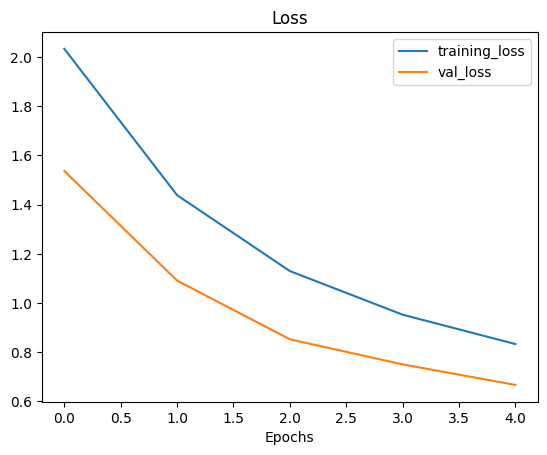

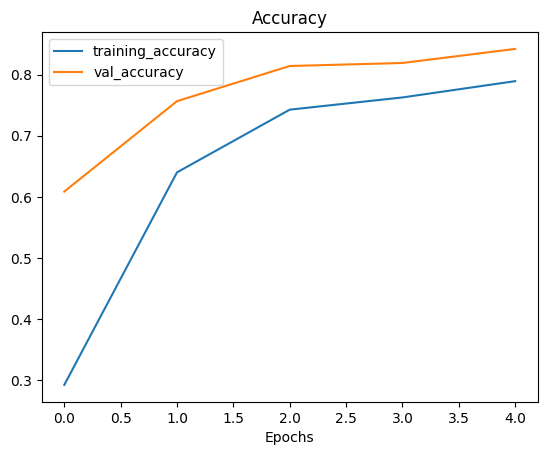

In [40]:
plot_loss_curves(history_10_percent_data_aug)

In [41]:
model_2.load_weights(checkpoint_path)
loaded_weights_model_results = model_2.evaluate(test_data)

79/79 [==============================] - 7s 89ms/step - loss: 0.6584 - accuracy: 0.8344


In [42]:
results_10_percent_data_aug == loaded_weights_model_results

False

In [43]:
import numpy as np
np.isclose(np.array(results_10_percent_data_aug), np.array(loaded_weights_model_results))

array([ True,  True])

In [44]:
print(np.array(results_10_percent_data_aug) - np.array(loaded_weights_model_results))

[1.78813934e-07 0.00000000e+00]


In [47]:
model_2.layers

In [48]:
for layer_number, layer in enumerate(model_2.layers):
  print(f"Layer number: {layer_number} | Layer name: {layer.name} | Layer type: {layer} | Trainable? {layer.trainable}")

Layer number: 0 | Layer name: input_layer | Layer type: <keras.engine.input_layer.InputLayer object at 0x00000214721B6A90> | Trainable? True
Layer number: 1 | Layer name: data_augmentation | Layer type: <keras.engine.sequential.Sequential object at 0x0000021470020D00> | Trainable? True
Layer number: 2 | Layer name: efficientnetv2-b0 | Layer type: <keras.engine.functional.Functional object at 0x000002147C8E4070> | Trainable? False
Layer number: 3 | Layer name: global_average_pooling_layer | Layer type: <keras.layers.pooling.global_average_pooling2d.GlobalAveragePooling2D object at 0x000002147C8EAFA0> | Trainable? True
Layer number: 4 | Layer name: output_layer | Layer type: <keras.layers.core.dense.Dense object at 0x000002147CB61280> | Trainable? True


In [49]:
model_2.summary()

Model: "model_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 data_augmentation (Sequenti  (None, 224, 224, 3)      0         
 al)                                                             
                                                                 
 efficientnetv2-b0 (Function  (None, None, None, 1280)  5919312  
 al)                                                             
                                                                 
 global_average_pooling_laye  (None, 1280)             0         
 r (GlobalAveragePooling2D)                                      
                                                                 
 output_layer (Dense)        (None, 10)                12810     
                                                           

In [50]:
model_2_base_model = model_2.layers[2]
model_2_base_model.name

'efficientnetv2-b0'

In [51]:
print(len(model_2_base_model.trainable_variables)) 

0


In [52]:
for layer_number, layer in enumerate(model_2_base_model.layers):
  print(layer_number, layer.name, layer.trainable)

0 input_7 False
1 rescaling_6 False
2 normalization_6 False
3 stem_conv False
4 stem_bn False
5 stem_activation False
6 block1a_project_conv False
7 block1a_project_bn False
8 block1a_project_activation False
9 block2a_expand_conv False
10 block2a_expand_bn False
11 block2a_expand_activation False
12 block2a_project_conv False
13 block2a_project_bn False
14 block2b_expand_conv False
15 block2b_expand_bn False
16 block2b_expand_activation False
17 block2b_project_conv False
18 block2b_project_bn False
19 block2b_drop False
20 block2b_add False
21 block3a_expand_conv False
22 block3a_expand_bn False
23 block3a_expand_activation False
24 block3a_project_conv False
25 block3a_project_bn False
26 block3b_expand_conv False
27 block3b_expand_bn False
28 block3b_expand_activation False
29 block3b_project_conv False
30 block3b_project_bn False
31 block3b_drop False
32 block3b_add False
33 block4a_expand_conv False
34 block4a_expand_bn False
35 block4a_expand_activation False
36 block4a_dwconv2 

In [53]:
model_2_base_model.trainable = True

for layer in model_2_base_model.layers[:-10]:
  layer.trainable = False


model_2.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
                metrics=["accuracy"])

In [54]:
for layer_number, layer in enumerate(model_2_base_model.layers):
  print(layer_number, layer.name, layer.trainable)

0 input_7 False
1 rescaling_6 False
2 normalization_6 False
3 stem_conv False
4 stem_bn False
5 stem_activation False
6 block1a_project_conv False
7 block1a_project_bn False
8 block1a_project_activation False
9 block2a_expand_conv False
10 block2a_expand_bn False
11 block2a_expand_activation False
12 block2a_project_conv False
13 block2a_project_bn False
14 block2b_expand_conv False
15 block2b_expand_bn False
16 block2b_expand_activation False
17 block2b_project_conv False
18 block2b_project_bn False
19 block2b_drop False
20 block2b_add False
21 block3a_expand_conv False
22 block3a_expand_bn False
23 block3a_expand_activation False
24 block3a_project_conv False
25 block3a_project_bn False
26 block3b_expand_conv False
27 block3b_expand_bn False
28 block3b_expand_activation False
29 block3b_project_conv False
30 block3b_project_bn False
31 block3b_drop False
32 block3b_add False
33 block4a_expand_conv False
34 block4a_expand_bn False
35 block4a_expand_activation False
36 block4a_dwconv2 

In [55]:
print(len(model_2.trainable_variables))

12


In [56]:
fine_tune_epochs = initial_epochs + 5

history_fine_10_percent_data_aug = model_2.fit(train_data_10_percent,
                                               epochs=fine_tune_epochs,
                                               validation_data=test_data,
                                               initial_epoch=history_10_percent_data_aug.epoch[-1],
                                               validation_steps=int(0.25 * len(test_data)),
                                               callbacks=[create_tensorboard_callback("transfer_learning", "10_percent_fine_tune_last_10")]) 

Saving TensorBoard log files to: transfer_learning/10_percent_fine_tune_last_10/20260827-193249
Epoch 5/10
24/24 [==============================] - 20s 535ms/step - loss: 0.7211 - accuracy: 0.8120 - val_loss: 0.4935 - val_accuracy: 0.8536
Epoch 6/10
24/24 [==============================] - 12s 507ms/step - loss: 0.6194 - accuracy: 0.8200 - val_loss: 0.4873 - val_accuracy: 0.8520
Epoch 7/10
24/24 [==============================] - 11s 463ms/step - loss: 0.5384 - accuracy: 0.8333 - val_loss: 0.4619 - val_accuracy: 0.8438
Epoch 8/10
24/24 [==============================] - 11s 469ms/step - loss: 0.5069 - accuracy: 0.8413 - val_loss: 0.4961 - val_accuracy: 0.8339
Epoch 9/10
24/24 [==============================] - 11s 463ms/step - loss: 0.4964 - accuracy: 0.8480 - val_loss: 0.4243 - val_accuracy: 0.8701
Epoch 10/10
24/24 [==============================] - 11s 461ms/step - loss: 0.4391 - accuracy: 0.8533 - val_loss: 0.4499 - val_accuracy: 0.8602


In [57]:
results_fine_tune_10_percent = model_2.evaluate(test_data)

79/79 [==============================] - 7s 86ms/step - loss: 0.4366 - accuracy: 0.8508


In [58]:
def compare_historys(original_history, new_history, initial_epochs=5):
    """
    Compares two model history objects.
    """
    # Get original history measurements
    acc = original_history.history["accuracy"]
    loss = original_history.history["loss"]

    print(len(acc))

    val_acc = original_history.history["val_accuracy"]
    val_loss = original_history.history["val_loss"]

    # Combine original history with new history
    total_acc = acc + new_history.history["accuracy"]
    total_loss = loss + new_history.history["loss"]

    total_val_acc = val_acc + new_history.history["val_accuracy"]
    total_val_loss = val_loss + new_history.history["val_loss"]

    print(len(total_acc))
    print(total_acc)

    # Make plots
    plt.figure(figsize=(8, 8))
    plt.subplot(2, 1, 1)
    plt.plot(total_acc, label='Training Accuracy')
    plt.plot(total_val_acc, label='Validation Accuracy')
    plt.plot([initial_epochs-1, initial_epochs-1],
              plt.ylim(), label='Start Fine Tuning') # reshift plot around epochs
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(2, 1, 2)
    plt.plot(total_loss, label='Training Loss')
    plt.plot(total_val_loss, label='Validation Loss')
    plt.plot([initial_epochs-1, initial_epochs-1],
              plt.ylim(), label='Start Fine Tuning') # reshift plot around epochs
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.xlabel('epoch')
    plt.show()

5
11
[0.2919999957084656, 0.6399999856948853, 0.7426666617393494, 0.762666642665863, 0.7893333435058594, 0.8119999766349792, 0.8199999928474426, 0.8333333134651184, 0.8413333296775818, 0.8479999899864197, 0.8533333539962769]


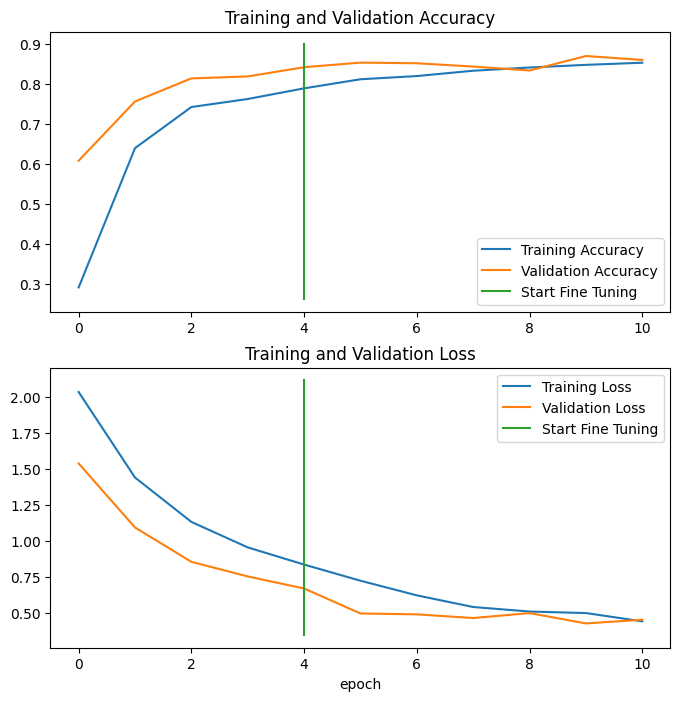

In [59]:
compare_historys(original_history=history_10_percent_data_aug,
                 new_history=history_fine_10_percent_data_aug,
                 initial_epochs=5)